In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
file_path = './housing.csv'
df = pd.read_csv(file_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [47]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [49]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [50]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [51]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [52]:
df.dropna(inplace=True)
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [53]:
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [54]:
df.shape

(20433, 10)

In [55]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9034
INLAND,6496
NEAR OCEAN,2628
NEAR BAY,2270
ISLAND,5


In [56]:
df['ocean_proximity']=df['ocean_proximity'].map({'NEAR BAY':0, '<1H OCEAN':1, 'INLAND':2, 'NEAR OCEAN':3, 'ISLAND':3})

In [57]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
1,9034
2,6496
3,2633
0,2270


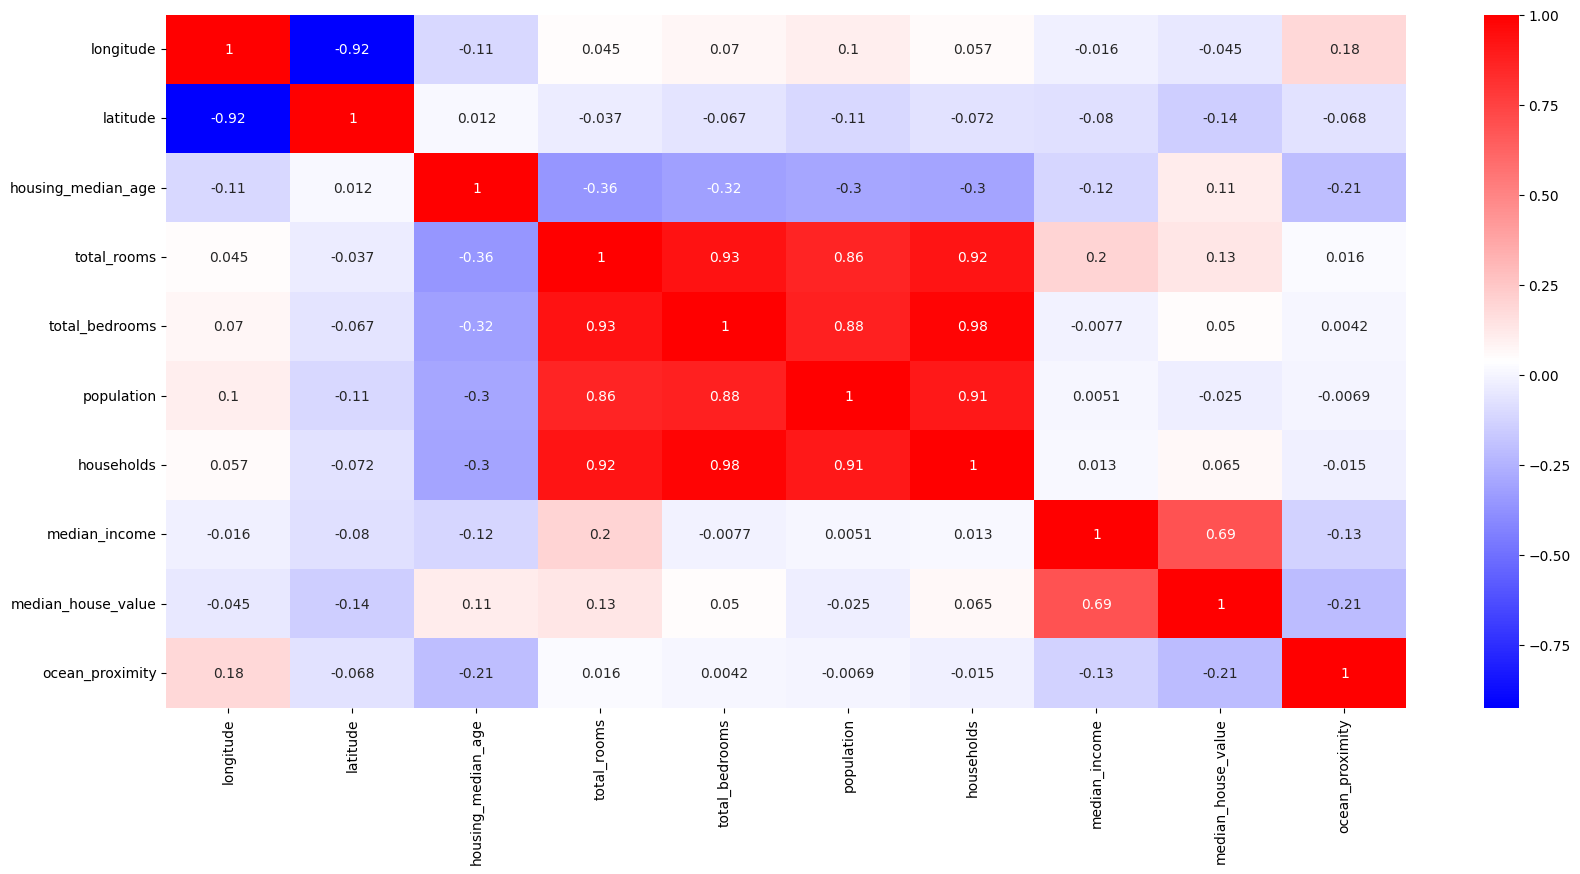

In [58]:
plt.figure(figsize=(20,9))
sns.heatmap(df.drop([], axis=1).corr(),annot=True, cmap="bwr")
plt.savefig("heatmap.png",dpi=300)

In [59]:
df=df.drop(['longitude','latitude'], axis=1)

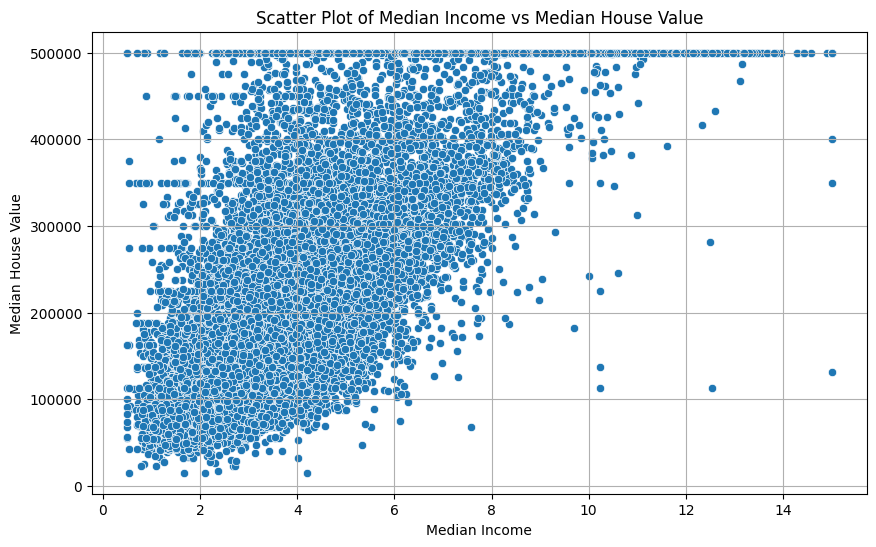

In [60]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df)
plt.title('Scatter Plot of Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

In [61]:
print(f"Shape of DataFrame before outlier removal: {df.shape}")

# Identify numerical columns (excluding the 'ocean_proximity' which is now encoded)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df.shape}")

Shape of DataFrame before outlier removal: (20433, 8)
Shape of DataFrame after outlier removal: (16724, 8)


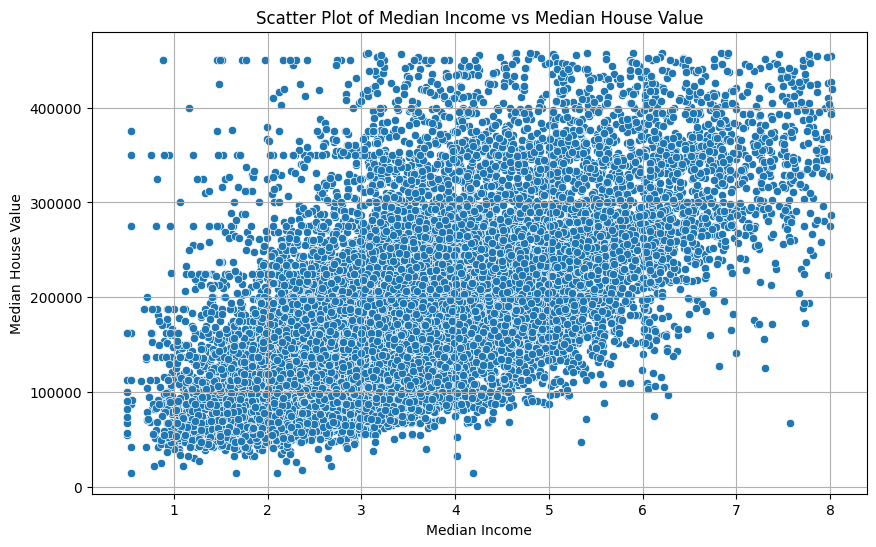

In [73]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='median_income', y='median_house_value', data=df)
plt.title('Scatter Plot of Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.grid(True)
plt.show()

In [66]:
y = df['median_house_value']
x = df.drop('median_house_value', axis=1)

In [80]:
from sklearn.model_selection import train_test_split

In [91]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (13379, 10)
Shape of x_test: (3345, 10)
Shape of y_train: (13379,)
Shape of y_test: (3345,)


In [92]:
from sklearn.preprocessing import StandardScaler

In [93]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train.values)
x_test_scaled = scaler.transform(x_test.values)

print("Scaled x_train (first 5 values):\n", x_train_scaled[:5])
print("Scaled x_test (first 5 values):\n", x_test_scaled[:5])

Scaled x_train (first 5 values):
 [[-1.10995946e+00 -1.78107380e+00 -1.86546993e+00 -1.91768953e+00
  -1.87346966e+00  1.23881026e+00 -5.79544024e-01 -2.63248834e-01
  -1.76413692e-03 -1.01793980e+00]
 [-3.76179979e-01 -4.52358051e-01 -7.27811605e-01 -4.55693272e-01
  -7.47314556e-01  1.63569387e-01  1.78403454e+00  4.14224986e-01
  -7.20391030e-01  4.55566056e-01]
 [-3.76179979e-01 -1.16281819e+00 -1.34383620e+00 -9.14607729e-01
  -1.25140303e+00 -4.02805239e-01  6.02245260e-01 -1.95454575e-02
  -6.47753085e-01  8.55715581e-01]
 [-1.02842841e+00 -1.32199232e+00 -8.56978052e-01 -1.49323900e+00
  -9.24281788e-01 -6.45211367e-01  1.78403454e+00 -1.03946211e+00
   2.56348678e+00 -1.40480623e+00]
 [ 1.13006343e-01  6.01685270e-01  1.16497364e+00  8.12216632e-01
   1.17251177e+00 -2.74862911e-01 -5.79544024e-01 -4.55125143e-01
   5.57473079e-01 -3.48591661e-01]]
Scaled x_test (first 5 values):
 [[ 0.84678583 -1.60248819 -1.80585464 -1.7997866  -1.8037553   2.62751328
   0.60224526  0.661055

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [95]:
# Make predictions on the scaled test set
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)
y_pred = linear_model.predict(x_test_scaled)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

Mean Absolute Error (MAE): 46118.610
Mean Squared Error (MSE): 3802650345.016
Root Mean Squared Error (RMSE): 61665.633
R-squared (R2): 0.555


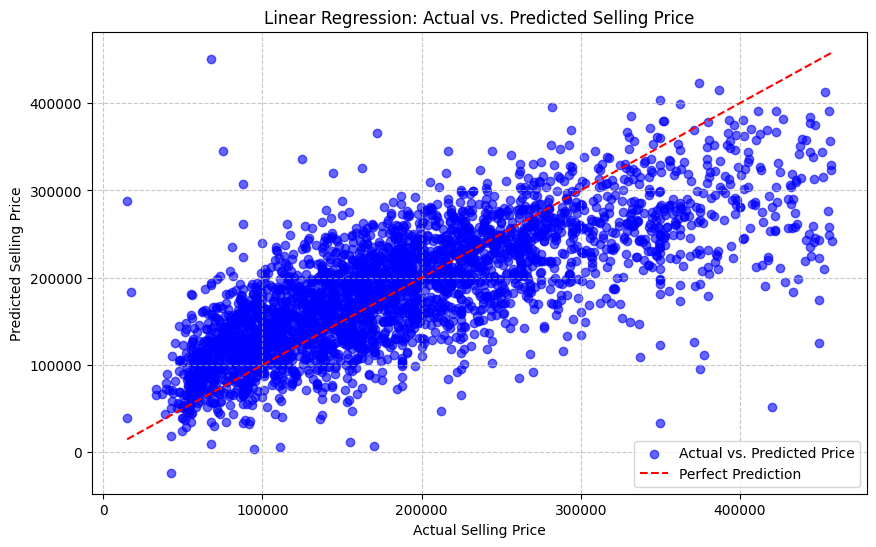

In [96]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Actual vs. Predicted Price', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Linear Regression: Actual vs. Predicted Selling Price')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [97]:
from sklearn.model_selection import GridSearchCV

In [98]:
lr=LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'copy_X': [True, False],
    'positive' : [True, False]
}

In [99]:
grid = GridSearchCV(estimator=lr, param_grid=param_grid, cv=5, scoring='r2',n_jobs=-1)

In [100]:
grid.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), n_jobs=-1,
             param_grid={'copy_X': [True, False],
                         'fit_intercept': [True, False],
                         'positive': [True, False]},
             scoring='r2')

In [101]:
print("Best parameters")
print(grid.best_params_)
print("Best score")
print(grid.best_score_)

Best parameters
{'copy_X': True, 'fit_intercept': True, 'positive': False}
Best score
0.5497612138412299


In [102]:
best_model= grid.best_estimator_

In [103]:
y_pred2 =best_model.predict(x_test_scaled)
print("For hyper parameter Tuning")
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")


For hyper parameter Tuning
Mean Absolute Error (MAE): 46118.610
Mean Squared Error (MSE): 3802650345.016
Root Mean Squared Error (RMSE): 61665.633
R-squared (R2): 0.555
